# Column Information

Based on data dictionary given by the dataset

---

| Field | Description |
|-------|------------|
| ID | Unique customer ID |
| Year_Birth | Birth year |
| Education | Education level |
| Marital_Status | Marital status |
| Income | Annual household income |
| Kidhome | # of children at home |
| Teenhome | # of teenagers at home |
| Dt_Customer | Enrollment date |
| Recency | Days since last purchase |
| MntWines | Wine spending (2 yrs) |
| MntFruits | Fruit spending (2 yrs) |
| MntMeatProducts | Meat spending (2 yrs) |
| MntFishProducts | Fish spending (2 yrs) |
| MntSweetProducts | Sweets spending (2 yrs) |
| MntGoldProds | Gold spending (2 yrs) |
| NumDealsPurchases | Discount purchases |
| NumWebPurchases | Web purchases |
| NumCatalogPurchases | Catalog purchases |
| NumStorePurchases | Store purchases |
| NumWebVisitsMonth | Website visits (last month) |
| AcceptedCmp1 | Accepted campaign 1 (0/1) |
| AcceptedCmp2 | Accepted campaign 2 (0/1) |
| AcceptedCmp3 | Accepted campaign 3 (0/1) |
| AcceptedCmp4 | Accepted campaign 4 (0/1) |
| AcceptedCmp5 | Accepted campaign 5 (0/1) |
| Response | Accepted last campaign (0/1) |
| Complain | Complaint in last 2 yrs (0/1) |
| Country | Customer country |

# Notebook Setup

In [1]:
# 1. Importing Libraries
import pandas as pd
import numpy as np

# 2. & 3. Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Data Prepping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 5. Modelling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 6. Evaluation
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import precision_recall_curve, average_precision_score

In [2]:
# 2. Data Loading
src = 'marketing_data.csv'
df = pd.read_csv(src)

# 1. Initial Data Overview

#### 1.1 Key Takeaways:
Dataset Structure:

*   2240 `Entries` * 28 `Columns`
*   Data Types: `datetime64`(1), `float64`(1), `int64`(23), `object`(3)
*   True/False treated as -> `0 (false) / 1 (true)`
*   24 missing values in `Income`

Unique Values for Categorical Data:

*   education_list = ['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic']
*   marital_status = ['Divorced', 'Single', 'Married', 'Together', 'Widow' 'YOLO', 'Alone', 'Absurd']
*   country_list = ['Spain', 'Canada', 'USA', 'Australia', 'Germany', 'India', 'Saudi Arabia', 'Mexico']

Key Notes:

*   Clean up the missing values before preciding with more in-depth analysis
*   Clean up values for marital_status (aggregate `YOLO`, `Alone`, `Absurd` into `Single` probably)



### 1.2 Data Preview

In [3]:
# 1. Dataset Description
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4    Income              2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [4]:
# 2. Dataset Preview
df.head(5).T

,0,1,2,3,4
ID,1826,1,10476,1386,5371
Year_Birth,1970,1961,1958,1967,1989
Education,Graduation,Graduation,Graduation,Graduation,Graduation
Marital_Status,Divorced,Single,Married,Together,Single
Income,84835.0,57091.0,67267.0,32474.0,21474.0
Kidhome,0,0,0,1,1
Teenhome,0,0,1,1,0
Dt_Customer,2014-06-16,2014-06-15,2014-05-13,2014-05-11,2014-04-08
Recency,0,0,0,0,0
MntWines,189,464,134,10,6


### 1.3 Identifying Dataset Quality

In [5]:
df.columns = df.columns.str.strip()

In [6]:
# 1. Checking Missing Values
missing_vals = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": df.isnull().sum() / len(df)
})
missing_vals

,Missing Values,Percentage
ID,0,0.000000
Year_Birth,0,0.000000
Education,0,0.000000
Marital_Status,0,0.000000
Income,24,0.010714
Kidhome,0,0.000000
Teenhome,0,0.000000
Dt_Customer,0,0.000000
Recency,0,0.000000
MntWines,0,0.000000


In [7]:
# 2. Previewing Data Spread
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [8]:
# 3. Focusing on Outliers
df[['Year_Birth', 'Income']].describe()

,Year_Birth,Income
count,2240.000000,2216.000000
mean,1968.805804,52247.251354
std,11.984069,25173.076661
min,1893.000000,1730.000000
25%,1959.000000,35303.000000
50%,1970.000000,51381.500000
75%,1977.000000,68522.000000
max,1996.000000,666666.000000


In [9]:
# 4. Previewing Unique Categorical Values
country_list = df['Country'].unique()
marital_status = df['Marital_Status'].unique()
education_list = df['Education'].unique()
print("Country List: ", *country_list)
print("Marital Status: ", *marital_status)
print("Education List: ", *education_list)

Country List:  Spain Canada USA Australia Germany India Saudi Arabia Mexico
Marital Status:  Divorced Single Married Together Widow YOLO Alone Absurd
Education List:  Graduation PhD 2n Cycle Master Basic


In [10]:
# 5. Identifying Duplicates
df.duplicated().sum()

np.int64(0)

# 2. Data Cleansing

In [11]:
df_temp = df.copy()

In [12]:
# 2.1. Handling Missing Values using Median Imputation
df_temp["Income"] = df_temp["Income"].fillna(df_temp["Income"].median())

In [13]:
# 2.2 Outlier Handling using IQR
outlier_cols = ["Year_Birth", "Income"]

def handle_IQR(df, outCols):
    for col in outCols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        upper = Q3 + 1.5 * IQR
        lower = Q1 - 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

df_temp = handle_IQR(df_temp, outlier_cols)
df_temp = df_temp.reset_index(drop=True)

# Sanity Check
df_temp[["Year_Birth", "Income"]].describe()

,Year_Birth,Income
count,2229.000000,2229.000000
mean,1968.888739,51619.504262
std,11.707430,20601.216248
min,1940.000000,1730.000000
25%,1959.000000,35416.000000
50%,1970.000000,51381.500000
75%,1977.000000,68118.000000
max,1996.000000,113734.000000


In [14]:
# 2.3. Handling Data Inconsistencies

# Correcting Data Types
df_temp["Dt_Customer"] = pd.to_datetime(df_temp["Dt_Customer"])

# Changing AcceptedCmp, Reponse, and Complain to Object type for Cat Analysis
df_temp['AcceptedCmp1'] = df_temp['AcceptedCmp1'].astype('object')
df_temp['AcceptedCmp2'] = df_temp['AcceptedCmp2'].astype('object')
df_temp['AcceptedCmp3'] = df_temp['AcceptedCmp3'].astype('object')
df_temp['AcceptedCmp4'] = df_temp['AcceptedCmp4'].astype('object')
df_temp['AcceptedCmp5'] = df_temp['AcceptedCmp5'].astype('object')
df_temp['Response'] = df_temp['Response'].astype('object')
df_temp['Complain'] = df_temp['Complain'].astype('object')

# Standardizing categories to ensure accurate group comparisons
cat_cols = ["Education", "Marital_Status", "Country"]
def cat_sanity_check(df, cols):
    for col in cols:
        print(df[col].value_counts())
        
print("=== Before ===:\n")       
cat_sanity_check(df_temp, cat_cols)

def standardize(df):  
    df['Marital_Status'] = df['Marital_Status'].replace(
        {'YOLO': 'Single', 'Alone': 'Single', 'Absurd': 'Single'}
    )

    df['Education'] = df['Education'].replace(
        {'2n Cycle': 'Master', 'Graduation': 'Bachelor'}
    )
    
    return df

df_temp = standardize(df_temp)

print("\n=== After ===:\n")
cat_sanity_check(df_temp, cat_cols)

=== Before ===:

Education
Graduation    1124
PhD            481
Master         369
2n Cycle       201
Basic           54
Name: count, dtype: int64
Marital_Status
Married     861
Together    575
Single      479
Divorced    230
Widow        77
Alone         3
YOLO          2
Absurd        2
Name: count, dtype: int64
Country
Spain           1091
Saudi Arabia     334
Canada           267
Australia        160
India            146
Germany          120
USA              108
Mexico             3
Name: count, dtype: int64

=== After ===:

Education
Bachelor    1124
Master       570
PhD          481
Basic         54
Name: count, dtype: int64
Marital_Status
Married     861
Together    575
Single      486
Divorced    230
Widow        77
Name: count, dtype: int64
Country
Spain           1091
Saudi Arabia     334
Canada           267
Australia        160
India            146
Germany          120
USA              108
Mexico             3
Name: count, dtype: int64


In [15]:
# 2.4. Derived Variables
def feature_engineering(df_inp):
    df = df_inp.copy()
    #Calculated from Year_Birth (2014 - Year_Birth) for better demographic profiling
    df['Age'] = 2014 - df['Year_Birth']
    
    # Combined KidHome + TeenHome to measure total household dependents
    df['Total_Children'] = df['Kidhome'] + df['Teenhome']
    
    #Summed all 6 product spending columns to create a single Key Performance Indicator (KPI)
    df['Total_Spent'] = (df['MntWines'] + df['MntFruits'] 
                         + df['MntMeatProducts'] + df['MntFishProducts']
                         + df['MntSweetProducts'] + df['MntGoldProds'])
    
    #Summed all 5 campaign columns to measure overall marketing engagement
    df['Total_Accepted_Cmp'] = (df['AcceptedCmp1'] + df['AcceptedCmp2'] 
                                + df['AcceptedCmp3'] + df['AcceptedCmp4']
                                + df['AcceptedCmp5'])
    df['Total_Accepted_Cmp'] = pd.to_numeric(df['Total_Accepted_Cmp'])
    
    return df

df_temp = feature_engineering(df_temp)

df_temp[['Age', 'Total_Children', 'Total_Spent', 'Total_Accepted_Cmp']].head().T

,0,1,2,3,4
Age,44,53,56,47,25
Total_Children,0,0,1,2,1
Total_Spent,1190,577,251,11,91
Total_Accepted_Cmp,0,1,0,0,1


In [16]:
# 2.5 Data Quality Review

# 3. Exploratory Data Analysis (EDA)

## 3.1 Key Descriptive Statistics

In [17]:
df_eda = df_temp.copy()

In [18]:
# Dropping Irrelevant Columns
drop_cols = ['Year_Birth'] #Already using Age
df_eda.drop(columns=drop_cols, inplace=True)

In [19]:
# Extra Feature Engineering for EDA

# 1. Total Spent from sum of all Mnt* products
spend_cols = [c for c in df_eda.columns if c.startswith("Mnt")]
df_eda['Total_Spent'] = df_eda[spend_cols].sum(axis=1)


# 2. Time-based trend analysis on Customer Enrollment Date
df_eda["Enroll_YearMonth"] = df_eda["Dt_Customer"].dt.to_period("M")
 
trend = (
    df_eda.groupby("Enroll_YearMonth")
    .agg(
        Avg_Total_Spent=("Total_Spent", "mean"),
        Avg_Income=("Income", "mean"),
        Response_Rate=("Response", "mean"),
        Customer_Count=("ID", "count"),
    )
    .reset_index()
)
trend["Enroll_YearMonth"] = trend["Enroll_YearMonth"].astype(str)

In [20]:
# 3.1.1. Statistical Overview of Data
df_eda.describe().T

,count,mean,min,25%,50%,75%,max,std
ID,2229.0,5589.296097,0.0,2829.0,5455.0,8420.0,11191.0,3244.840538
Income,2229.0,51619.504262,1730.0,35416.0,51381.5,68118.0,113734.0,20601.216248
Kidhome,2229.0,0.444594,0.0,0.0,0.0,1.0,2.0,0.538636
Teenhome,2229.0,0.507402,0.0,0.0,0.0,1.0,2.0,0.544735
Dt_Customer,2229,2013-07-10 05:20:25.841184,2012-07-30 00:00:00,2013-01-16 00:00:00,2013-07-08 00:00:00,2013-12-30 00:00:00,2014-06-29 00:00:00,NaN
Recency,2229.0,49.106326,0.0,24.0,49.0,74.0,99.0,28.946476
MntWines,2229.0,304.991476,0.0,24.0,176.0,505.0,1493.0,336.761943
MntFruits,2229.0,26.348587,0.0,2.0,8.0,33.0,199.0,39.76406
MntMeatProducts,2229.0,165.283984,0.0,16.0,67.0,231.0,1725.0,219.336589
MntFishProducts,2229.0,37.642441,0.0,3.0,12.0,50.0,259.0,54.700548


In [21]:
# 3.1.2. Spending by Category
product_category = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_eda[product_category].describe().T

,count,mean,std,min,25%,50%,75%,max
MntWines,2229.0,304.991476,336.761943,0.0,24.0,176.0,505.0,1493.0
MntFruits,2229.0,26.348587,39.764060,0.0,2.0,8.0,33.0,199.0
MntMeatProducts,2229.0,165.283984,219.336589,0.0,16.0,67.0,231.0,1725.0
MntFishProducts,2229.0,37.642441,54.700548,0.0,3.0,12.0,50.0,259.0
MntSweetProducts,2229.0,27.161507,41.338945,0.0,1.0,8.0,34.0,263.0
MntGoldProds,2229.0,44.113055,52.091255,0.0,9.0,24.0,56.0,362.0


In [22]:
# 3.1.3. Purchashing Channels
channels = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df_eda[channels].describe().T

,count,mean,std,min,25%,50%,75%,max
NumDealsPurchases,2229.0,2.319874,1.895252,0.0,1.0,2.0,3.0,15.0
NumWebPurchases,2229.0,4.100045,2.775461,0.0,2.0,4.0,6.0,27.0
NumCatalogPurchases,2229.0,2.636608,2.796161,0.0,0.0,2.0,4.0,28.0
NumStorePurchases,2229.0,5.812472,3.242144,0.0,3.0,5.0,8.0,13.0


In [23]:
# 3.1.4. Household
household = ['Kidhome', 'Teenhome', 'Total_Children']
df_eda[household].describe().T

,count,mean,std,min,25%,50%,75%,max
Kidhome,2229.0,0.444594,0.538636,0.0,0.0,0.0,1.0,2.0
Teenhome,2229.0,0.507402,0.544735,0.0,0.0,0.0,1.0,2.0
Total_Children,2229.0,0.951996,0.751976,0.0,0.0,1.0,1.0,3.0


In [24]:
# 3.1.5. Customer's Engagement
engagement = ['Recency', 'NumWebVisitsMonth', 'Total_Accepted_Cmp']
df_eda[engagement].describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,2229.0,49.106326,28.946476,0.0,24.0,49.0,74.0,99.0
NumWebVisitsMonth,2229.0,5.334231,2.414981,0.0,3.0,6.0,7.0,20.0
Total_Accepted_Cmp,2229.0,0.298789,0.679597,0.0,0.0,0.0,0.0,4.0


## 3.2 Visualizations

In [25]:
# Specifying Columns
numvis = ['Age', 'Income', 'Total_Children', 'Total_Spent', 'NumWebVisitsMonth', 'Total_Accepted_Cmp']
catvis = ['Education', 'Marital_Status', 'Country', 'Response', 'Complain']

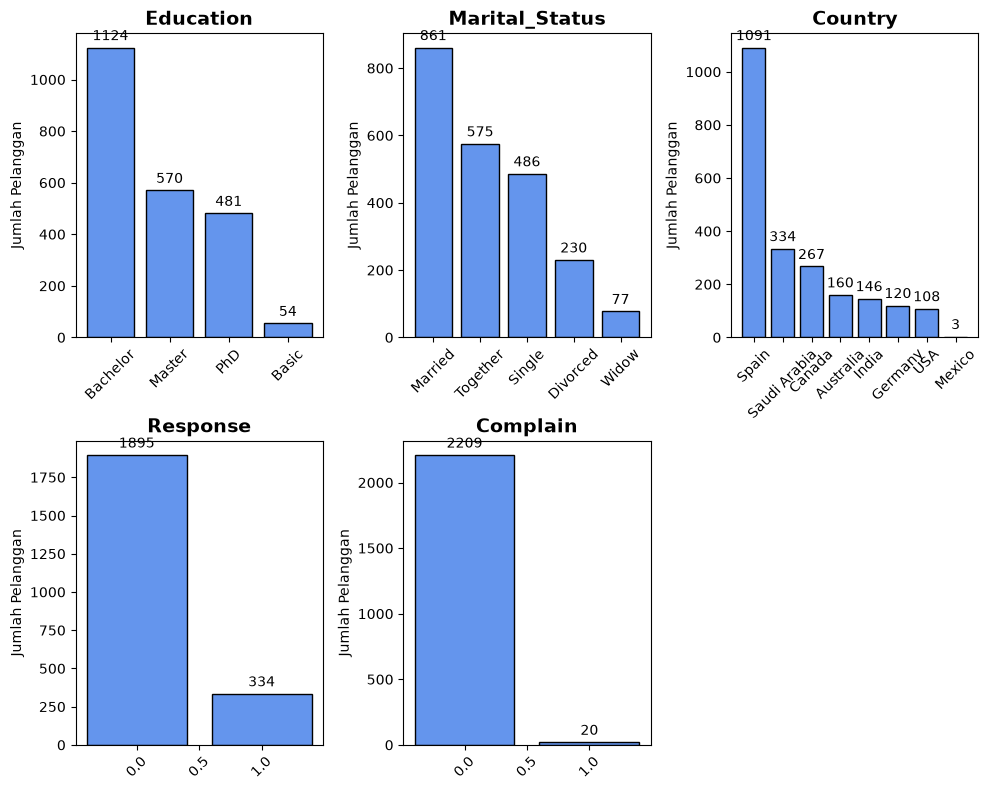

In [26]:
# 3.2.1. Bar Chart Analysis
def check_univariate_cat(df, catCols):
    n = len(catCols)
    rows = -(-n // 3)
    plt.figure(figsize=(10, 8))

    for i, col in enumerate(catCols, 1):
        plt.subplot(rows, 3, i)
        counts = df[col].value_counts()
        bars = plt.bar(counts.index, counts.values, color='cornflowerblue', edgecolor='black')
        plt.bar_label(bars, padding=3, fmt='%d', fontsize=10)
        plt.title(f'{col}', fontsize=14, fontweight='bold')
        plt.ylabel('Jumlah Pelanggan')
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

check_univariate_cat(df_eda, catvis)

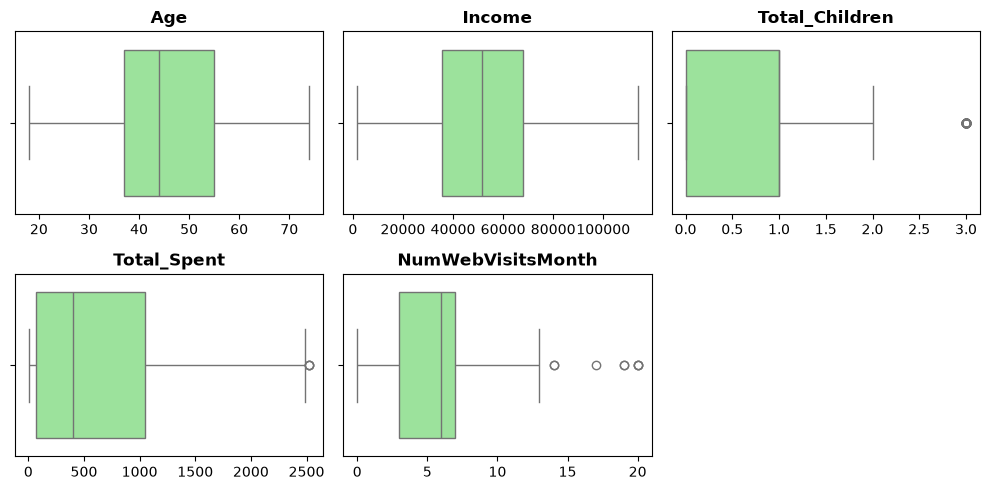

In [27]:
# 3.2.2. Box Plot Analysis
def check_univariate_num(df, numCols):
    n = len(numCols)
    rows = -(-n // 3)
    plt.figure(figsize=(10,5))

    for i, col in enumerate(numCols, 1):
        # Skipping Total_Accepted_Cmp because its only 1 - 5
        if col == 'Total_Accepted_Cmp':
            continue
        plt.subplot(rows, 3, i)
        sns.boxplot(x=df[col], color='lightgreen')
        plt.title(f'{col}', fontweight='bold')
        plt.xlabel('')
    plt.tight_layout()
    plt.show()

check_univariate_num(df_eda, numvis)

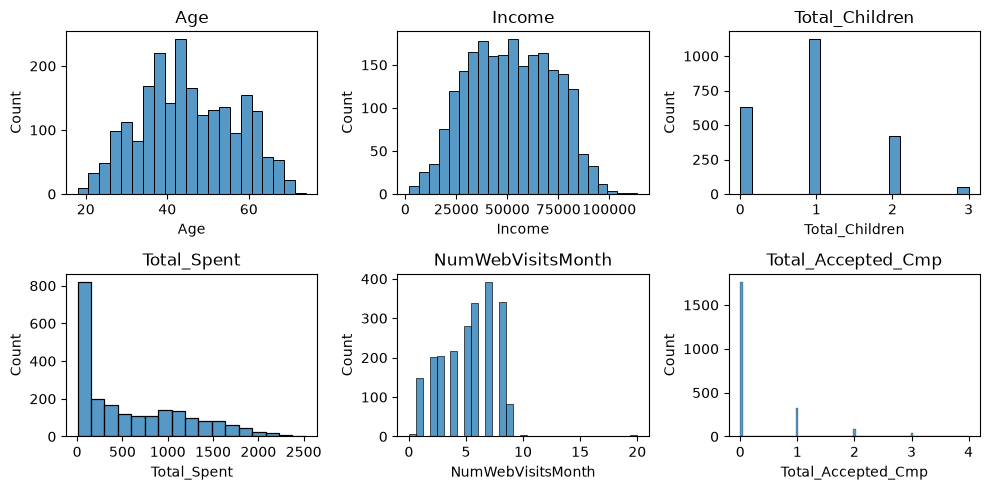

In [28]:
# 3.2.3. Histogram Analysis
def check_skew_num(df, numCols):
  slots = len(numCols)
  rows = -(-slots//3)
  plt.figure(figsize=(10,5))
  for i, col in enumerate(numCols, 1):
    plt.subplot(rows, 3, i)
    sns.histplot(df[col])
    plt.title(col)
  plt.tight_layout()
  plt.show()

check_skew_num(df_eda, numvis)

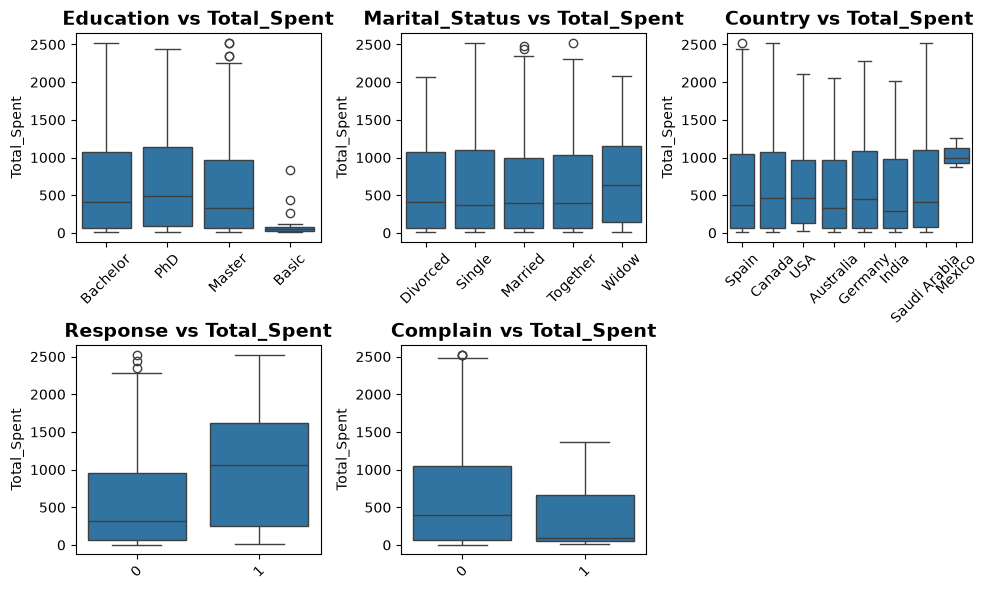

In [29]:
# 3.2.4. Bivariate Analysis on Total Spent using Box Plot
def check_bivariate_cat_num(df, catCols, targetCol):
    n = len(catCols)
    rows = -(-n // 3)
    plt.figure(figsize=(10, 6))

    for i, col in enumerate(catCols, 1):
        plt.subplot(rows, 3, i)
        sns.boxplot(x=df[col], y=df[targetCol])
        plt.title(f'{col} vs {targetCol}', fontsize=14, fontweight='bold')
        plt.xlabel('')
        plt.ylabel(targetCol)
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

check_bivariate_cat_num(df_eda, catvis, 'Total_Spent')

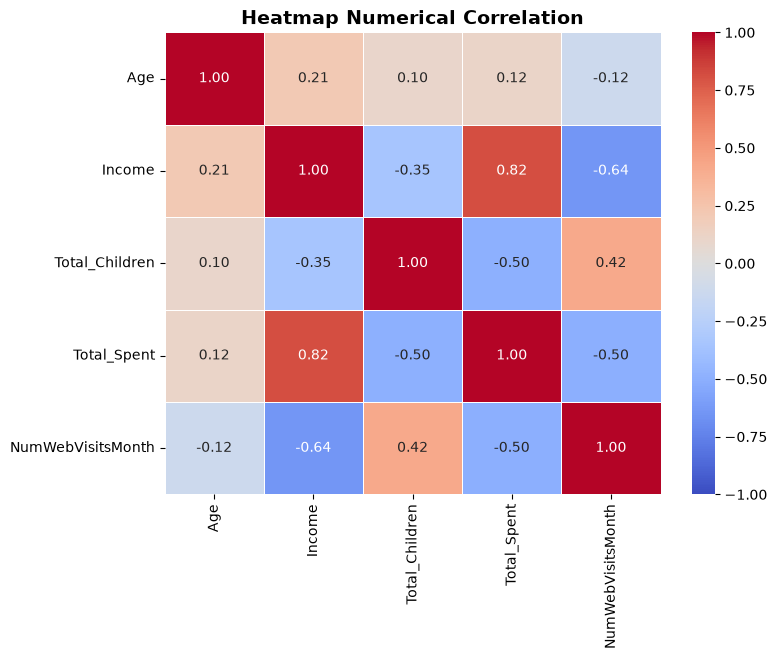

In [30]:
# 3.2.5. Bivariate Analysis using Heatmap
cols_to_check = ['Age', 'Income', 'Total_Children', 'Total_Spent', 'NumWebVisitsMonth']
corr_matrix = df_eda[cols_to_check].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Numerical Correlation', fontsize=14, fontweight='bold')
plt.show()

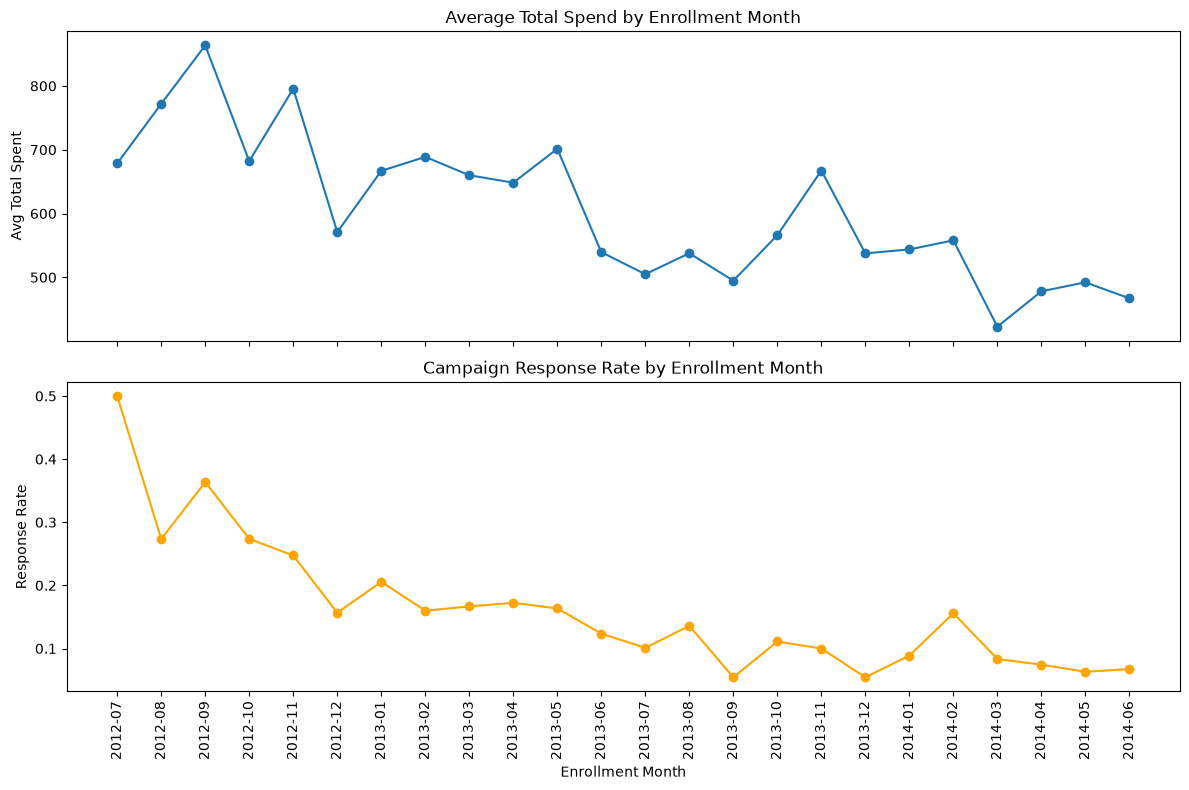

In [31]:
# 3.2.6 Time-based Trend Analysis
df_eda["Enroll_YearMonth"] = df_eda["Dt_Customer"].dt.to_period("M")
 
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(trend["Enroll_YearMonth"], trend["Avg_Total_Spent"], marker="o")
axes[0].set_title("Average Total Spend by Enrollment Month")
axes[0].set_ylabel("Avg Total Spent")
axes[0].tick_params(axis="x", rotation=90)
 
axes[1].plot(trend["Enroll_YearMonth"], trend["Response_Rate"], marker="o", color="orange")
axes[1].set_title("Campaign Response Rate by Enrollment Month")
axes[1].set_ylabel("Response Rate")
axes[1].set_xlabel("Enrollment Month")
axes[1].tick_params(axis="x", rotation=90)
 
plt.tight_layout()
plt.show()
plt.savefig("time_trend_analysis.png", dpi=150)
plt.close()


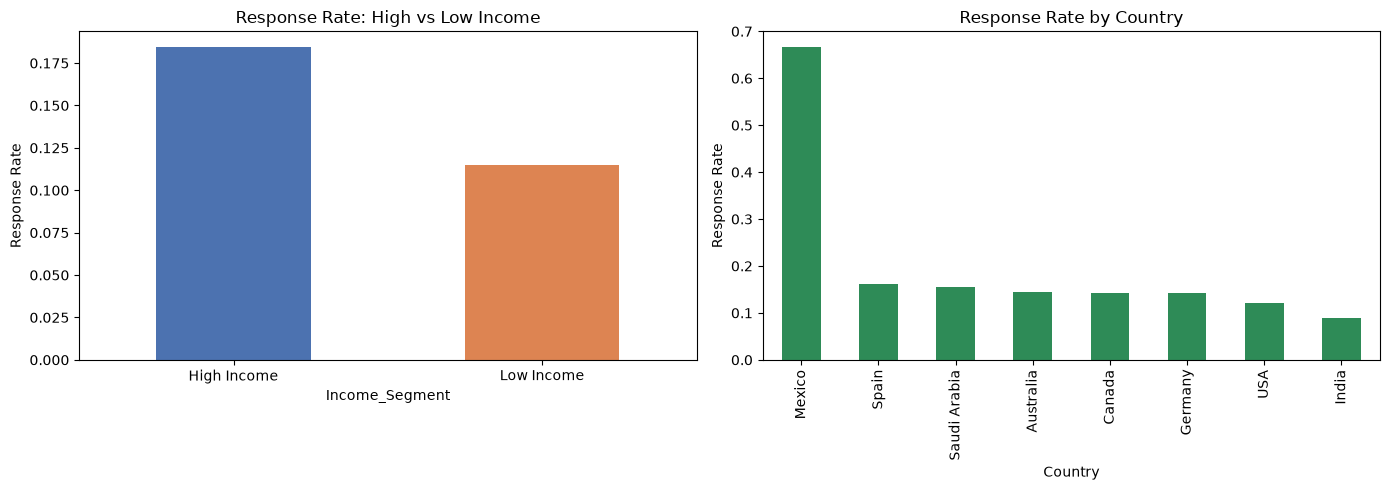

In [32]:
# 3.2.7 Segmented/Subgroup Analysis

# High vs Low Income
income_median = df_eda["Income"].median()
df_eda["Income_Segment"] = np.where(df_eda["Income"] >= income_median, "High Income", "Low Income")


income_segment_summary = df_eda.groupby("Income_Segment").agg(
    Avg_Total_Spent=("Total_Spent", "mean"),
    Avg_Recency=("Recency", "mean"),
    Response_Rate=("Response", "mean"),
    Customer_Count=("ID", "count"),
)


# By Country
country_summary = (
    df_eda.groupby("Country")
    .agg(
        Avg_Income=("Income", "mean"),
        Avg_Total_Spent=("Total_Spent", "mean"),
        Response_Rate=("Response", "mean"),
        Customer_Count=("ID", "count"),
    )
    .sort_values("Response_Rate", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
income_segment_summary["Response_Rate"].plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Response Rate: High vs Low Income")
axes[0].set_ylabel("Response Rate")
axes[0].tick_params(axis="x", rotation=0)


country_summary["Response_Rate"].plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("Response Rate by Country")
axes[1].set_ylabel("Response Rate")


plt.tight_layout()
plt.show()

## 3.3 Statistical Analysis

In [33]:
from scipy.stats import chi2_contingency, f_oneway, ttest_ind, mannwhitneyu, chi2_contingency
from statsmodels.stats.oneway import anova_oneway

from itertools import combinations
 
import pingouin as pg
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor


### 3.3.1 Hypothesis Testing

In [34]:
TARGET = 'Response'
ALPHA = 0.05

numerical_columns = df_eda.select_dtypes(include=['int64', 'float64']).columns.to_list()
numerical_columns = [c for c in numerical_columns if c not in ['ID']]

categorical_columns = df_eda.select_dtypes(include='object').columns.to_list()
categorical_columns = [c for c in categorical_columns if c not in ['Response']]

/tmp/ipykernel_23835/3539436277.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_eda.select_dtypes(include='object').columns.to_list()


In [35]:
# 1. Welch's ANOVA test
for col in numerical_columns:
    groups = [df_eda[df_eda[TARGET] == value][col].dropna() for value in df_eda[TARGET].unique()]
    res = anova_oneway(groups, use_var='unequal')
    p = res.pvalue
    sig = "[* Significant]" if p < ALPHA else "[not significant]"
    print(f'{col}: {p:.15f} -> {sig}')

Income: 0.000000000000426 -> [* Significant]
Kidhome: 0.000043840986956 -> [* Significant]
Teenhome: 0.000000000000010 -> [* Significant]
Recency: 0.000000000000000 -> [* Significant]
MntWines: 0.000000000000000 -> [* Significant]
MntFruits: 0.000000280429729 -> [* Significant]
MntMeatProducts: 0.000000000000000 -> [* Significant]
MntFishProducts: 0.000003328254004 -> [* Significant]
MntSweetProducts: 0.000000823261104 -> [* Significant]
MntGoldProds: 0.000000002669769 -> [* Significant]
NumDealsPurchases: 0.882636134101037 -> [not significant]
NumWebPurchases: 0.000000000000501 -> [* Significant]
NumCatalogPurchases: 0.000000000000000 -> [* Significant]
NumStorePurchases: 0.071629966664250 -> [not significant]
NumWebVisitsMonth: 0.750561505439000 -> [not significant]
Age: 0.395034439235393 -> [not significant]
Total_Children: 0.000000000000003 -> [* Significant]
Total_Spent: 0.000000000000000 -> [* Significant]
Total_Accepted_Cmp: 0.000000000000000 -> [* Significant]


In [36]:
df_eda['Complain'].value_counts()

Complain
0    2209
1      20
Name: count, dtype: int64

In [37]:
# 2. Chi2
for col in categorical_columns:
    _, p, _, _ = chi2_contingency(pd.crosstab(df_eda[col], df_eda[TARGET]))
    sig = "[* Significant]" if p < ALPHA else "[not significant]"
    print(f'{col}: {p:.15f} -> {sig}')

Education: 0.000082935872600 -> [* Significant]
Marital_Status: 0.000000000204572 -> [* Significant]
AcceptedCmp3: 0.000000000000000 -> [* Significant]
AcceptedCmp4: 0.000000000000000 -> [* Significant]
AcceptedCmp5: 0.000000000000000 -> [* Significant]
AcceptedCmp1: 0.000000000000000 -> [* Significant]
AcceptedCmp2: 0.000000000000011 -> [* Significant]
Complain: 1.000000000000000 -> [not significant]
Country: 0.079511682976004 -> [not significant]
Income_Segment: 0.000005241078602 -> [* Significant]


In [38]:
# 3. A/B Testing
g1, g0 = df_eda[df_eda.Response == 1], df_eda[df_eda.Response == 0]
for metric in ["Total_Spent", "Income"]:
    t_stat, t_p = ttest_ind(g1[metric], g0[metric], equal_var=False)
    u_stat, u_p = mannwhitneyu(g1[metric], g0[metric], alternative="two-sided")
    print(f"\n{metric}: Response 1 vs 0")
    print(f"  Welch's t-test:    t={t_stat:.3f}, p={t_p:.2e}")
    print(f"  Mann-Whitney U:    U={u_stat:.0f}, p={u_p:.2e}")



Total_Spent: Response 1 vs 0
  Welch's t-test:    t=10.868, p=2.60e-24
  Mann-Whitney U:    U=438952, p=1.40e-29

Income: Response 1 vs 0
  Welch's t-test:    t=7.483, p=4.26e-13
  Mann-Whitney U:    U=400349, p=1.04e-14


### 3.3.2 Correlation Analysis

In [39]:
df_eda["Country_Grp"] = df_eda["Country"].where(df_eda["Country"].map(df_eda["Country"].value_counts()) >= 30, "Other")
df_eda['Response'] = pd.to_numeric(df_eda['Response'], errors='coerce').astype(int)

numeric_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["ID"]]
 
pearson_corr = df_eda[numeric_cols].corr(method="pearson")
spearman_corr = df_eda[numeric_cols].corr(method="spearman")
 
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(pearson_corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set_title("Pearson Correlation")
axes[0].set_xticks(range(len(numeric_cols))); axes[0].set_xticklabels(numeric_cols, rotation=90)
axes[0].set_yticks(range(len(numeric_cols))); axes[0].set_yticklabels(numeric_cols)
 
axes[1].imshow(spearman_corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_title("Spearman Correlation")
axes[1].set_xticks(range(len(numeric_cols))); axes[1].set_xticklabels(numeric_cols, rotation=90)
axes[1].set_yticks(range(len(numeric_cols))); axes[1].set_yticklabels(numeric_cols)
plt.tight_layout()
plt.savefig("correlation_heatmaps.png", dpi=150)
plt.close()
 
 
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))
 
 
cat_cols = ["Education", "Marital_Status", "Country_Grp"]
cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for c1, c2 in combinations(cat_cols, 2):
    v = cramers_v(df_eda[c1], df_eda[c2])
    cramers_matrix.loc[c1, c2] = cramers_matrix.loc[c2, c1] = v
for c in cat_cols:
    cramers_matrix.loc[c, c] = 1.0
print("\nCramer's V (categorical-categorical association):")
print(cramers_matrix)
 
 
def correlation_ratio(categories, values):
    cats = pd.Series(categories).values
    vals = pd.Series(values).values
    ss_between = sum(
        len(vals[cats == c]) * (vals[cats == c].mean() - vals.mean()) ** 2 for c in np.unique(cats)
    )
    ss_total = sum((vals - vals.mean()) ** 2)
    return np.sqrt(ss_between / ss_total)
 
 
print("\nCorrelation ratio (eta) — categorical vs continuous:")
for cat in cat_cols:
    eta = correlation_ratio(df_eda[cat], df_eda["Total_Spent"])
    print(f"  {cat} -> Total_Spent: eta = {eta:.3f}")
 
# Partial correlation: does Total_Spent still relate to Response once Income is controlled for?
pc = pg.partial_corr(data=df_eda, x="Total_Spent", y="Response", covar="Income")
pc_col = "p-val" if "p-val" in pc.columns else "p_val"
print(f"\nPartial correlation Total_Spent~Response | controlling Income:\n{pc[['n','r',pc_col]]}")



Cramer's V (categorical-categorical association):
                Education  Marital_Status  Country_Grp
Education        1.000000        0.048179     0.050870
Marital_Status   0.048179        1.000000     0.068483
Country_Grp      0.050870        0.068483     1.000000

Correlation ratio (eta) — categorical vs continuous:
  Education -> Total_Spent: eta = 0.148
  Marital_Status -> Total_Spent: eta = 0.045
  Country_Grp -> Total_Spent: eta = 0.050

Partial correlation Total_Spent~Response | controlling Income:
            n         r         p_val
pearson  2229  0.219454  1.058438e-25


# 4. Data Prep

## 4.1. Data Cleaning

In [40]:
df_prep = df.copy()

In [41]:
# 4.1.1. Stripping Column Names
df_prep.columns = df_prep.columns.str.strip()

In [42]:
# 4.1.2. Dropping NA
df_prep = df_prep.dropna().reset_index(drop=True)

In [43]:
# 4.1.3. Changing Data Types
df_prep['Dt_Customer'] = pd.to_datetime(df_prep['Dt_Customer'])

In [44]:
# 4.1.4. Standardizing Categories

# using previous standardize function
df_prep = standardize(df_prep)

## 4.2. Data Splitting

In [45]:
target = 'Response'
X = df_prep.drop(columns=target)
y = df_prep[target]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=41,
    stratify=y
)

In [47]:
print("=== Dataset Shape ===")
print(f"X_train: {X_train.shape[0]} rows")
print(f"X_test:  {X_test.shape[0]} rows")
print(f"Total:   {X_train.shape[0] + X_test.shape[0]} rows")

=== Dataset Shape ===
X_train: 1772 rows
X_test:  444 rows
Total:   2216 rows


In [48]:
print("=== Class Distribution ===")
print(f"Y_train Distribution:")
print(y_train.value_counts())
print(f"\nY_test Distribution: ")
print(y_test.value_counts())

=== Class Distribution ===
Y_train Distribution:
Response
0    1506
1     266
Name: count, dtype: int64

Y_test Distribution: 
Response
0    377
1     67
Name: count, dtype: int64


## 4.3. Data Preprocessing

In [49]:
# 4.3.1 Fit(on Train) and Transform (on Train & Test)

# Fitting
capped_boundaries = {}
for col in outlier_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    capped_boundaries[col] = (lower, upper)

# Transform
for col in outlier_cols:
    lower, upper = capped_boundaries[col]
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)


In [50]:
# 4.3.2. Feature Engineering

# Same feature engineering done during EDA
X_train = feature_engineering(X_train)
X_test = feature_engineering(X_test)

In [53]:
# 4.3.3. Dropping Redudant Columns
redundant_cols = ['ID', 'Year_Birth', 'Dt_Customer',
                  'Kidhome', 'Teenhome',
                  'MntWines', 'MntFruits', 'MntMeatProducts',
                  'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
                  'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4',
                  'AcceptedCmp5', 'Complain',
                  # From statistical analyis
                  'NumDealsPurchases', 'NumWebVisitsMonth', 'NumStorePurchases', 'Age'
                  ]

X_train.drop(columns=redundant_cols, inplace=True)
X_test.drop(columns=redundant_cols, inplace=True)

In [54]:
# 4.3.4 Ordinal Encoding for Education
EDUCATION_ORDER = {
    'Basic': 0,
    'Bachelor': 1,
    'Master': 2,
    'PhD': 3
}
X_train['Education'] = X_train['Education'].map(EDUCATION_ORDER)
X_test['Education'] = X_test['Education'].map(EDUCATION_ORDER)

In [55]:
# 4.3.4 One Hote Encoding
OHE_COLS = ['Marital_Status', 'Country']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
encoder.fit(X_train[OHE_COLS])

ohe_cols_names = encoder.get_feature_names_out(OHE_COLS)

X_train_ohe = pd.DataFrame(encoder.transform(X_train[OHE_COLS]), columns=ohe_cols_names, index=X_train.index)
X_test_ohe  = pd.DataFrame(encoder.transform(X_test[OHE_COLS]),  columns=ohe_cols_names, index=X_test.index)

X_train = X_train.drop(columns=OHE_COLS).join(X_train_ohe)
X_test  = X_test.drop(columns=OHE_COLS).join(X_test_ohe)

In [56]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [57]:
# 4.3.5 Multicollinearity Identification
vif_data = pd.DataFrame()
vif_data['Feature'] = pd.DataFrame(X_train).columns
vif_data['VIF'] = [variance_inflation_factor(X_train, i) for i in range(X_train.shape[1])]
vif_data.sort_values('VIF', ascending=False)

,Feature,VIF
1,Income,19.636823
6,Total_Spent,10.101354
17,Country_Spain,6.103362
0,Education,4.937294
4,NumCatalogPurchases,4.839373
3,NumWebPurchases,4.654424
8,Marital_Status_Married,3.812743
2,Recency,3.728605
5,Total_Children,3.445609
10,Marital_Status_Together,2.905810


In [58]:
# Capture X_train now so it can be later compared
X_train_unscaled = X_train.copy()
X_test_unscaled = X_test.copy()

In [59]:
# 4.3.5 Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Modelling

In [60]:
# 5.1. Defining Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [61]:
# 5.2 Model Prediction
y_pred = model.predict(X_test)

# 6. Evaluation

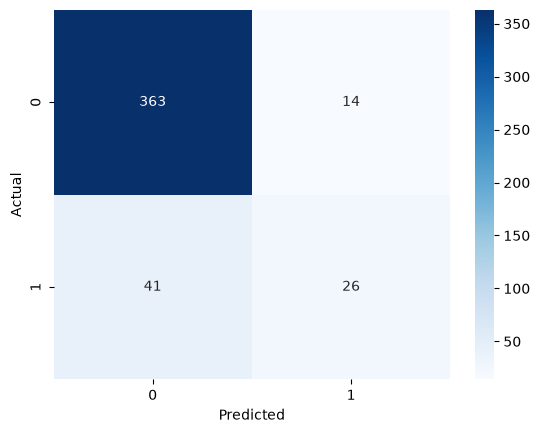

In [62]:
# 6.1 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [63]:
# 6.2 Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93       377
           1       0.65      0.39      0.49        67

    accuracy                           0.88       444
   macro avg       0.77      0.68      0.71       444
weighted avg       0.86      0.88      0.86       444



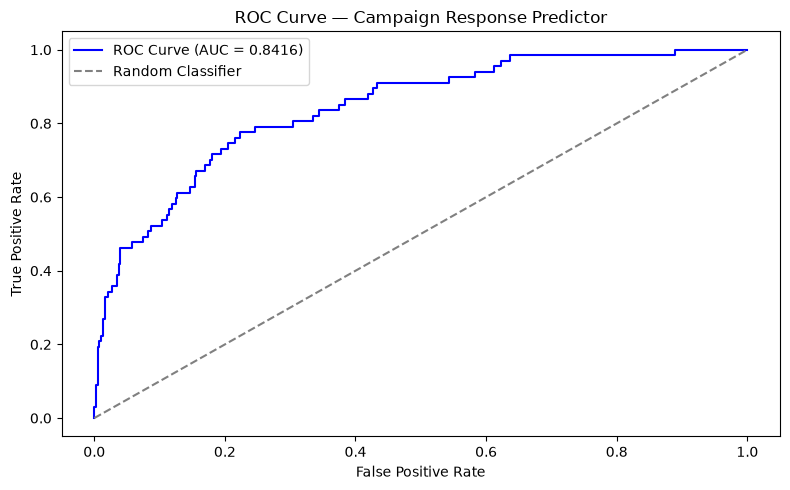

0.8416010135001385

In [64]:
# 6.3 ROC Curve
def plot_roc_curve(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    
    roc_auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    
    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve — Campaign Response Predictor')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return roc_auc

plot_roc_curve(model, X_test, y_test)

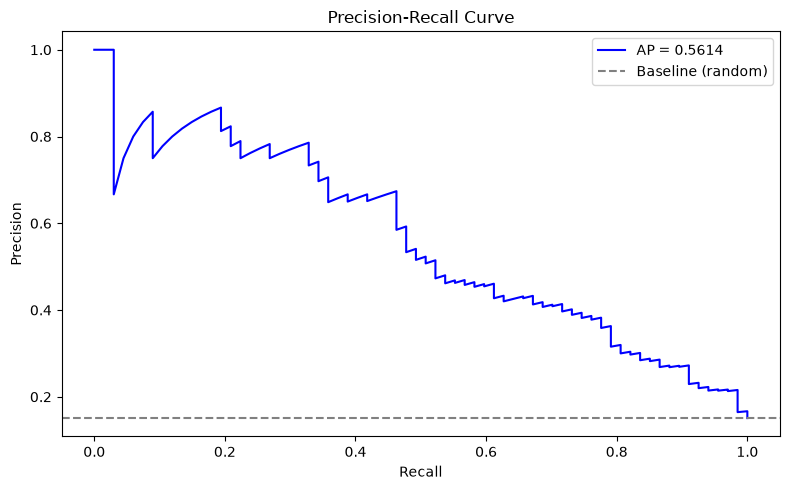

0.5613763342012459

In [65]:
# 6.4 Precision Recall Curve
def plot_pr_curve(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)

    plt.figure(figsize=(8, 5))
    plt.plot(recall, precision, color='blue', label=f'AP = {ap:.4f}')
    plt.axhline(y=y_test.mean(), color='gray', linestyle='--', label='Baseline (random)')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return ap

plot_pr_curve(model, X_test, y_test)


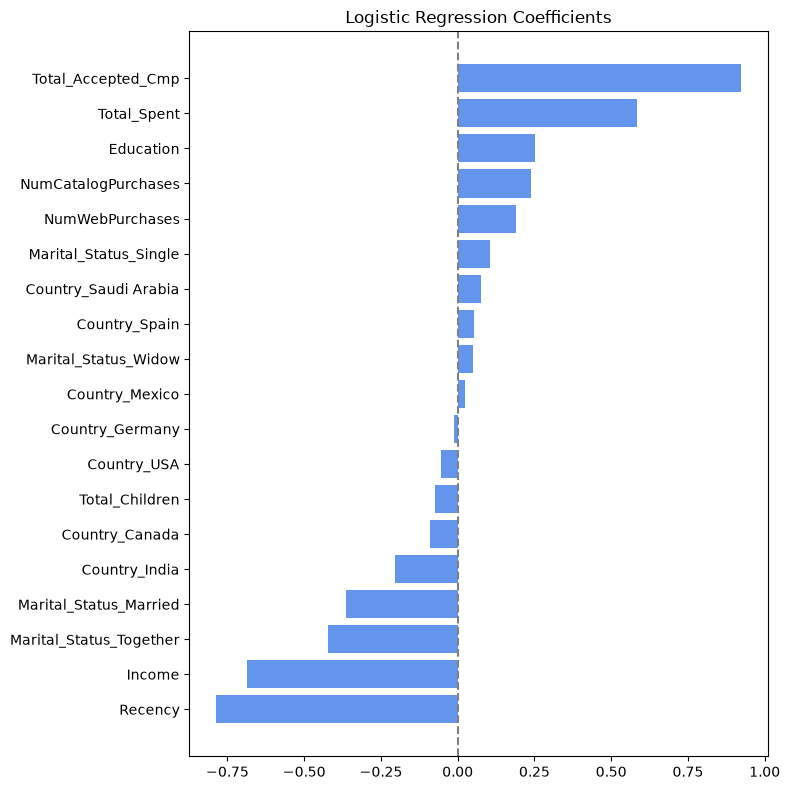

In [66]:
# 6.5 Feature Importance
def plot_feature_importance(model, feature_names):
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': model.coef_[0]
    }).sort_values('Coefficient', ascending=True)

    plt.figure(figsize=(8, 8))
    plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='cornflowerblue')
    plt.axvline(x=0, color='gray', linestyle='--')
    plt.title('Logistic Regression Coefficients')
    plt.tight_layout()
    plt.show()

plot_feature_importance(model, X_train_unscaled.columns)